# Fenrir: PCA orientado a clustering
Esta versión deja de fijar el PCA en 2 componentes desde el principio y pasa a seleccionar el espacio reducido por varianza explicada acumulada.
Además compara varios escalados y varios algoritmos de clustering usando métricas complementarias, y expone diagnósticos útiles del PCA: scree plot, círculo de correlaciones, contribuciones y calidad de representación (`cos2`).

In [ ]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

candidate_project_roots = [
    Path.cwd(),
    Path.cwd() / "fenrir",
    Path.cwd().parent,
    Path.cwd().parent / "fenrir",
]

try:
    import fenrir as fenrir_package
except ModuleNotFoundError:
    FENRIR_PROJECT_ROOT = next(
        (
            path
            for path in candidate_project_roots
            if (path / "core.py").exists() and (path / "__init__.py").exists()
        ),
        None,
    )
    if FENRIR_PROJECT_ROOT is None:
        raise FileNotFoundError(
            "No se encontro fenrir instalado ni una copia local del proyecto. "
            "Instala la libreria o coloca este notebook junto al repo."
        )

    package_parent = FENRIR_PROJECT_ROOT.parent
    if str(package_parent) not in sys.path:
        sys.path.insert(0, str(package_parent))

    import fenrir as fenrir_package

fenrir_package = importlib.reload(fenrir_package)
Fenrir = fenrir_package.Fenrir
package_file = getattr(fenrir_package, "__file__", None)
if package_file is None:
    raise RuntimeError("No se pudo resolver la ruta del paquete fenrir cargado.")

FENRIR_PROJECT_ROOT = Path(package_file).resolve().parent
FENRIR_EXAMPLES_DIR = FENRIR_PROJECT_ROOT / "examples"

print(f"Fenrir importado desde: {FENRIR_PROJECT_ROOT}")

Fenrir importado desde paquete: c:\Users\alrodriguez\Downloads\fenrir


## Bootstrap del paquete
Este notebook intenta importar primero `fenrir` desde el entorno activo. Si no lo encuentra, busca una copia local del proyecto junto al notebook y evita depender de rutas absolutas de Windows.

## Demo con Titanic
Este ejemplo busca primero `Titanic-Dataset.csv` junto al notebook, en `examples/` o en `data/`. Si no lo encuentra, intenta cargar Titanic desde OpenML para que la demo siga siendo portable al moverla a otro PC o al repo.
La variable objetivo se declara con `target="Survived"`. Fenrir la separa del PCA y del clustering, y la usa despues para perfilar los clusters, estratificar la evaluacion holdout y compararlos con una referencia externa.
La libreria no se adapta ad hoc a Titanic: lo que cambia es el modo de uso. Ahora expone tambien una lista libre de variables influyentes, un dataframe con la columna de cluster, un `groupby` por cluster y una busqueda del subconjunto mas compacto que mejora el clustering.

In [ ]:
from pathlib import Path

candidate_csv_paths = [
    Path.cwd() / "Titanic-Dataset.csv",
    Path.cwd() / "examples" / "Titanic-Dataset.csv",
    Path.cwd() / "data" / "Titanic-Dataset.csv",
    Path.cwd().parent / "Titanic-Dataset.csv",
    Path.cwd().parent / "examples" / "Titanic-Dataset.csv",
    Path.cwd().parent / "data" / "Titanic-Dataset.csv",
]

if "FENRIR_PROJECT_ROOT" in globals():
    candidate_csv_paths.extend(
        [
            FENRIR_PROJECT_ROOT.parent / "Titanic-Dataset.csv",
            FENRIR_PROJECT_ROOT / "Titanic-Dataset.csv",
            FENRIR_PROJECT_ROOT / "data" / "Titanic-Dataset.csv",
        ]
    )

if "FENRIR_EXAMPLES_DIR" in globals():
    candidate_csv_paths.extend(
        [
            FENRIR_EXAMPLES_DIR / "Titanic-Dataset.csv",
            FENRIR_EXAMPLES_DIR / "data" / "Titanic-Dataset.csv",
        ]
    )

csv_path = next((path for path in candidate_csv_paths if path.exists()), None)
if csv_path is not None:
    demo = pd.read_csv(csv_path)
    data_source = f"CSV local: {csv_path}"
else:
    try:
        from sklearn.datasets import fetch_openml
    except ImportError as exc:
        raise FileNotFoundError(
            "No se encontro 'Titanic-Dataset.csv' y tampoco esta disponible "
            "fetch_openml para descargar el dataset de respaldo."
        ) from exc

    try:
        openml_dataset = fetch_openml("titanic", version=1, as_frame=True)
    except Exception as exc:
        raise FileNotFoundError(
            "No se encontro 'Titanic-Dataset.csv' en rutas relativas y tampoco se pudo "
            "cargar Titanic desde OpenML. Coloca el CSV junto al notebook o en 'examples/' o 'data/'."
        ) from exc

    demo = openml_dataset.frame.copy()
    demo = demo.rename(
        columns={
            "survived": "Survived",
            "pclass": "Pclass",
            "name": "Name",
            "sex": "Sex",
            "age": "Age",
            "sibsp": "SibSp",
            "parch": "Parch",
            "ticket": "Ticket",
            "fare": "Fare",
            "cabin": "Cabin",
            "embarked": "Embarked",
        }
    )
    if "PassengerId" not in demo.columns:
        demo.insert(0, "PassengerId", range(1, len(demo) + 1))

    preferred_columns = [
        "PassengerId",
        "Survived",
        "Pclass",
        "Name",
        "Sex",
        "Age",
        "SibSp",
        "Parch",
        "Ticket",
        "Fare",
        "Cabin",
        "Embarked",
    ]
    demo = demo.loc[:, [column for column in preferred_columns if column in demo.columns]].copy()
    demo["Survived"] = pd.to_numeric(demo["Survived"], errors="coerce")
    data_source = "OpenML Titanic fallback"

print(f"Dataset cargado desde: {data_source}")
print(f"Forma del dataset: {demo.shape}")
display(demo.head())

Dataset cargado desde: C:\Users\alrodriguez\Downloads\Titanic-Dataset.csv
Forma del dataset: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
fenrir_config = {
    "target": "Survived",
    "exclude_columns": ["PassengerId", "Name", "Ticket", "Cabin"],
    "variance_threshold": 0.9,
    "cluster_range": range(2, 8),
    "algorithms": ("kmeans", "gmm", "agglomerative"),
    "max_categories": 12,
    "random_state": 42,
}

analysis_config = {
    "top_n": 5,
    "leaderboard_top_n": 6,
    "holdout_top_n": 5,
    "compact_max_features": 5,
    "compact_criterion": "holdout_silhouette",
    "compact_include_holdout": None,
    "test_size": 0.25,
    "n_splits": 2,
    "stratify_target": True,
    "min_cluster_share": 0.01,
    "include_stability": True,
    "stability_sample_fraction": 0.8,
    "stability_n_splits": 3,
    "stability_top_n": 5,
    "stability_stratify_target": True,
}

plot_config = {
    "figsize": (18, 12),
    "correlation_top_n": 10,
    "contribution_top_n": 8,
    "quality_top_n": 8,
    "projection_components": 2,
}

dashboard_config = {
    "metric_rows": [
        "explained_variance",
        "variance_first_two",
        "silhouette",
        "davies_bouldin",
        "ari",
        "nmi",
        "v_measure",
    ],
    "holdout_rows": 5,
    "compact_rows": 5,
    "stability_rows": 5,
}

parameter_preview = pd.Series(
    {
        "target": fenrir_config["target"],
        "cluster_range": list(fenrir_config["cluster_range"]),
        "compact_criterion": analysis_config["compact_criterion"],
        "n_splits": analysis_config["n_splits"],
        "min_cluster_share": analysis_config["min_cluster_share"],
        "include_stability": analysis_config["include_stability"],
        "stability_sample_fraction": analysis_config["stability_sample_fraction"],
        "stability_n_splits": analysis_config["stability_n_splits"],
    },
    name="valor",
).to_frame()

print("Ajusta aqui los parametros principales de Fenrir")
display(parameter_preview)

Ajusta aqui los parametros principales de Fenrir


,valor
target,Survived
cluster_range,"[2, 3, 4, 5, 6, 7]"
compact_criterion,holdout_silhouette
n_splits,2
min_cluster_share,0.01
include_stability,True
stability_sample_fraction,0.8
stability_n_splits,3


## Parametros de usuario
Ajusta esta celda antes de reejecutar la demo si quieres cambiar el rango de clusters, la busqueda compacta o la validacion holdout sin tocar el resto del notebook.

In [4]:
fenrir = Fenrir(demo, **fenrir_config)
clusters = fenrir.fit_predict()
clustered_demo = fenrir.clustered_dataframe(
    include_components=True,
    n_components=plot_config["projection_components"],
)
metric_view = fenrir.metric_report().loc[:, ["metric", "value", "acceptable", "interpretation"]]
influential_list = fenrir.list_influential_variables(top_n=max(8, analysis_config["top_n"]))
cluster_size_view = fenrir.cluster_size_report()
cluster_group_view = fenrir.cluster_groupby(top_n=analysis_config["top_n"])

print("Mejor configuracion")
display(fenrir.best_configuration().rename("valor").to_frame())

print("Lectura orientativa de metricas")
display(metric_view)

print("Resumen del preprocesado")
display(fenrir.preprocessing_report())

print("Comparativa por escalado")
display(fenrir.scaler_report())

print("Top del leaderboard")
display(fenrir.summary(top_n=analysis_config["leaderboard_top_n"]))

print("Lista libre de variables mas influyentes")
print(influential_list)

print("Tamano de clusters")
display(cluster_size_view)

print("Groupby por cluster")
display(cluster_group_view)

print("Relacion cluster-objetivo")
display(fenrir.cluster_target_report(normalize="index"))

print("Dataframe con cluster anadido")
display(clustered_demo.head())

Mejor configuracion


,valor
scaler_name,MinMaxScaler
algorithm,kmeans
n_clusters,7
n_components,4
explained_variance,0.941764
variance_first_two,0.694011
silhouette,0.755663
calinski_harabasz,1439.237245
davies_bouldin,0.496487


Lectura orientativa de metricas


,metric,value,acceptable,interpretation
0,explained_variance,0.941764,0.70+ aceptable | 0.85+ fuerte | 0.90+ muy fuerte,Muy fuerte
1,variance_first_two,0.694011,0.50+ suele permitir graficos 2D legibles,Muy util para visualizacion 2D
2,silhouette,0.755663,<0.25 flojo | 0.25-0.50 usable | 0.50-0.70 bue...,Separacion excelente
3,davies_bouldin,0.496487,<0.60 excelente | <1.00 bueno | 1.00-1.50 regu...,Muy bueno
4,calinski_harabasz,1439.237245,sin umbral absoluto,Solo interpretable en comparacion con otras co...
5,ari,0.121484,0.30+ senal | 0.50+ bueno | 0.75+ muy fuerte,Alineacion debil
6,nmi,0.141336,0.30+ senal | 0.50+ bueno | 0.75+ muy fuerte,Alineacion debil
7,v_measure,0.141336,0.30+ senal | 0.50+ bueno | 0.75+ muy fuerte,Alineacion debil
8,n_clusters,7.000000,aceptable si es estable entre splits,Valido si tambien es estable en holdout y sigu...
9,n_components,4.000000,mantener solo las necesarias,"Mejor cuanto mas pequeno sea, si mantiene el r..."


Resumen del preprocesado


...

,cluster_size,cluster_share,Sex,Embarked,Pclass,Age,Fare,Survived
cluster,,,,,,,,
0,265,0.2974,male,S,3.0000,26.5748,13.3071,0.1283
1,75,0.0842,female,C,1.7067,29.0317,75.2986,0.8800
2,203,0.2278,female,S,2.1970,27.7715,38.7409,0.6897
3,36,0.0404,female,Q,2.8889,24.2917,12.6350,0.7500
4,176,0.1975,male,S,1.5511,35.4562,34.3670,0.2443
5,95,0.1066,male,C,2.0105,32.9988,48.2621,0.3053
6,41,0.0460,male,Q,2.9268,30.9375,13.8389,0.0732


Relacion cluster-objetivo


Survived,0,1
cluster,,
0,0.871698,0.128302
1,0.120000,0.880000
2,0.310345,0.689655
3,0.250000,0.750000
4,0.755682,0.244318
5,0.694737,0.305263
6,0.926829,0.073171


Dataframe con cluster anadido


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,cluster,pca_PC1,pca_PC2
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,-0.625789,0.216756
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,1.268368,-0.800649
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,2,0.701432,0.663485
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0.853331,0.505512
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,-0.629635,0.207650


## Workbench interactivo

Define la variable objetivo, reajusta Fenrir, lanza validacion profunda, exporta tablas y graficos, guarda presets persistentes en JSON, genera un Excel ejecutivo multihja y alterna entre vista completa, solo PCA, solo clustering o comparacion lado a lado de presets.

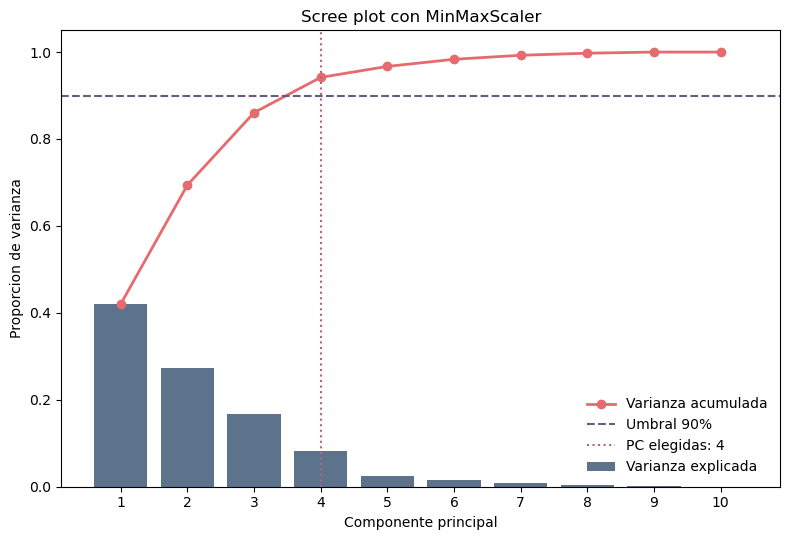

In [5]:
fenrir_workbench = fenrir.interactive_workbench(
    fenrir_config=fenrir_config,
    analysis_config=analysis_config,
)
fenrir_tables = fenrir_workbench

display(fenrir_workbench)

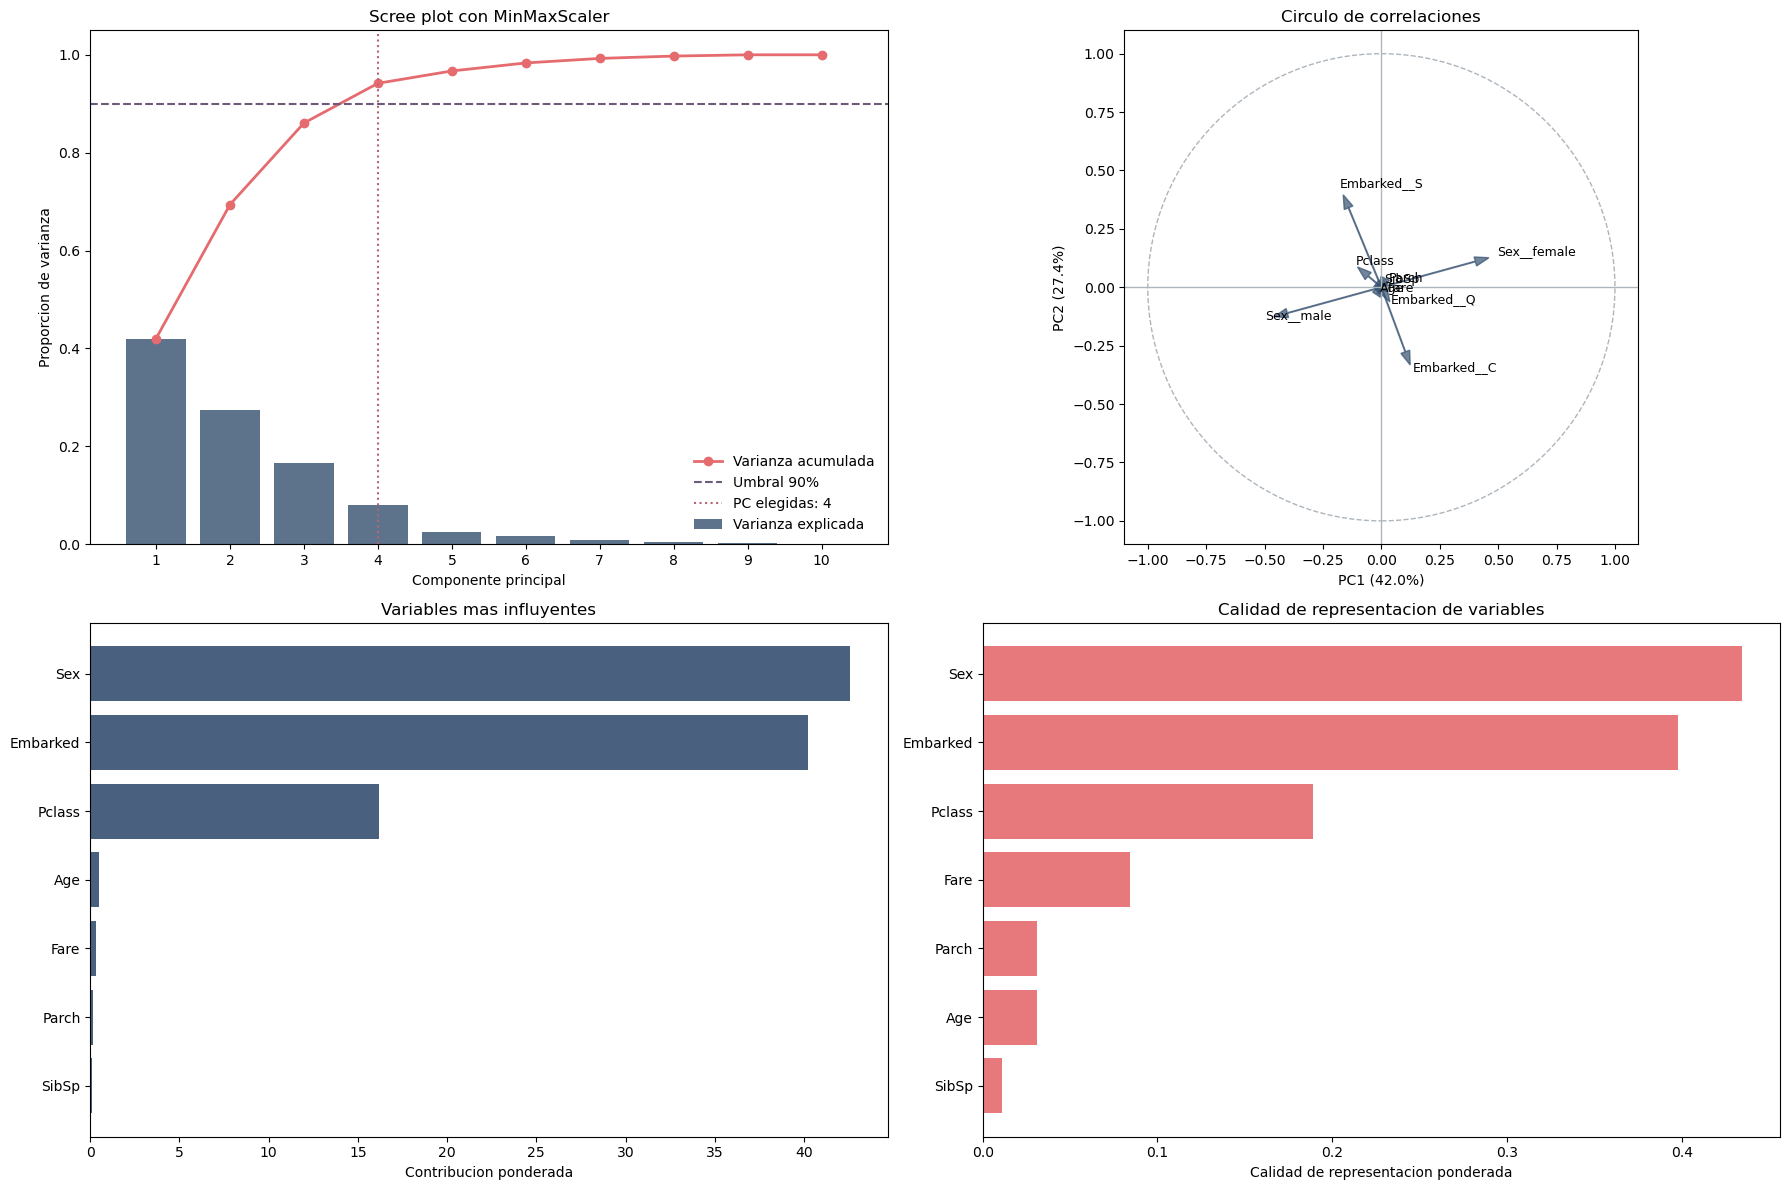

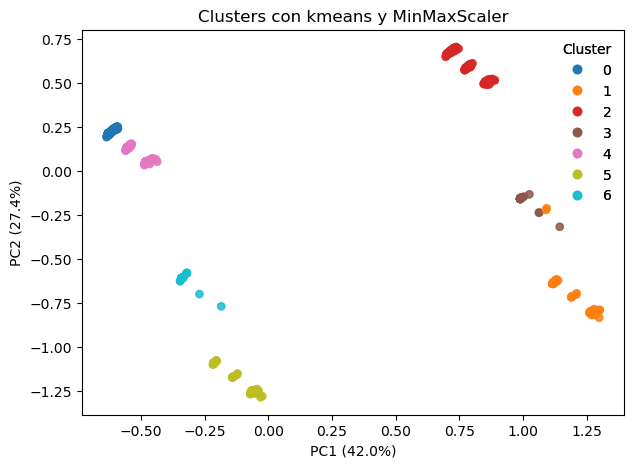

In [6]:
fig, axes = plt.subplots(2, 2, figsize=plot_config["figsize"])
fenrir.plot_scree(ax=axes[0, 0])
fenrir.plot_correlation_circle(ax=axes[0, 1], top_n=plot_config["correlation_top_n"])
fenrir.plot_feature_contributions(ax=axes[1, 0], top_n=plot_config["contribution_top_n"])
fenrir.plot_feature_quality(ax=axes[1, 1], top_n=plot_config["quality_top_n"])
plt.tight_layout()
plt.show()

fenrir.plot_clusters()
plt.show()

In [7]:
report = fenrir.analysis_report(**analysis_config)

best = report["best_configuration"]
embedding = fenrir.transform()
source_report = fenrir.source_feature_report(top_n=plot_config["contribution_top_n"])
top_variables = report["influential_variables"]
selected_dataset = fenrir.influential_dataset(top_n=analysis_config["top_n"], include_target=True)
target_profile = report["cluster_target_report"]
holdout_summary = report["holdout_summary"]
holdout_top = report["holdout_top"]
holdout_view = holdout_top.loc[:, [
    column
    for column in [
        "scaler_name",
        "algorithm",
        "n_clusters",
        "n_components",
        "test_silhouette_mean",
        "test_davies_bouldin_mean",
        "test_v_measure_mean",
        "test_nmi_mean",
    ]
    if column in holdout_top.columns
]]
subset_search = report["compact_subset_search"]
subset_view = subset_search.loc[:, [
    column
    for column in [
        "n_selected_features",
        "selected_variables",
        "test_silhouette_mean",
        "test_davies_bouldin_mean",
        "silhouette",
        "explained_variance",
        "davies_bouldin",
        "min_cluster_size",
        "min_cluster_share",
        "selection_status",
    ]
    if column in subset_search.columns
]]
best_compact_variables = report["best_compact_variables"]
fenrir_compact = fenrir.best_influential_model()
compact_best = report["best_compact_configuration"]
compact_group_view = report["best_compact_groupby"]
stability_summary = report["stability_summary"]
stability_top = report["stability_top"]
stability_view = stability_top.loc[:, [
    column
    for column in [
        "split",
        "sample_size",
        "ari_vs_base",
        "nmi_vs_base",
        "v_measure_vs_base",
        "same_algorithm",
        "same_n_clusters",
        "same_n_components",
        "min_cluster_size",
    ]
    if column in stability_top.columns
]] if stability_top is not None else pd.DataFrame()

assert len(clusters) == len(demo)
assert embedding.shape[1] == int(best["n_components"])
assert best["explained_variance"] >= fenrir.variance_threshold
assert np.isfinite(float(best["silhouette"]))
assert len(top_variables) == analysis_config["top_n"]
assert set(top_variables).issubset(demo.columns)
assert set(top_variables).issubset(selected_dataset.columns)
assert fenrir.target_name_ == fenrir_config["target"]
assert {"weighted_contribution", "weighted_cos2"}.issubset(source_report.columns)
assert target_profile is not None and target_profile.shape[0] >= 2
assert "cluster" in clustered_demo.columns
assert not holdout_summary.empty
assert {"test_silhouette_mean", "test_davies_bouldin_mean"}.issubset(holdout_top.columns)
assert not subset_search.empty
assert {"selection_status"}.issubset(subset_search.columns)
assert subset_search.iloc[0]["selection_status"] == "valido"
assert len(best_compact_variables) >= 2
assert set(best_compact_variables).issubset(demo.columns)
assert len(fenrir_compact.predict()) == len(demo)
assert compact_best["explained_variance"] >= fenrir_compact.variance_threshold
assert np.isfinite(float(compact_best["silhouette"]))
assert stability_summary is not None and not stability_summary.empty
assert stability_top is not None and not stability_top.empty
assert {"ari_vs_base_mean", "same_configuration_rate", "stability_reading"}.issubset(stability_summary.columns)

print("Top holdout estratificado")
display(holdout_view)

print("Busqueda compacta guiada por holdout")
display(subset_view)

print("Lista compacta accesible para el usuario:", best_compact_variables)
print("Configuracion del mejor subconjunto compacto")
display(compact_best.rename("valor").to_frame())

print("Estabilidad por remuestreo")
display(stability_summary)
display(stability_view)

print("Groupby del mejor subconjunto compacto")
display(compact_group_view)

Top holdout estratificado


,scaler_name,algorithm,n_clusters,n_components,test_silhouette_mean,test_davies_bouldin_mean,test_v_measure_mean,test_nmi_mean
0,MinMaxScaler,agglomerative,7,4,0.758889,0.450851,0.125726,0.125726
1,MinMaxScaler,gmm,7,4,0.758889,0.450851,0.125726,0.125726
2,MinMaxScaler,kmeans,7,4,0.758889,0.450851,0.125726,0.125726
3,MinMaxScaler,agglomerative,6,4,0.716051,0.616242,0.109475,0.109475
4,MinMaxScaler,gmm,6,4,0.716051,0.616242,0.109475,0.109475


Busqueda compacta guiada por holdout


,n_selected_features,selected_variables,test_silhouette_mean,test_davies_bouldin_mean,silhouette,explained_variance,davies_bouldin,min_cluster_size,min_cluster_share,selection_status
0,3,"[Sex, Embarked, Pclass]",0.794346,3.314343e-01,0.823021,0.912252,0.515232,52,0.058361,valido
1,4,"[Sex, Embarked, Pclass, Age]",0.768431,4.429105e-01,0.763819,0.976789,0.488839,36,0.040404,valido
2,5,"[Sex, Embarked, Pclass, Age, Fare]",0.765278,4.485363e-01,0.761577,0.971329,0.494496,36,0.040404,valido
3,2,"[Sex, Embarked]",1.000000,1.706549e-08,1.000000,0.996668,0.000000,2,0.002245,cluster minimo insuficiente


Lista compacta accesible para el usuario: ['Sex', 'Embarked', 'Pclass']
Configuracion del mejor subconjunto compacto


...

Estabilidad por remuestreo


,n_splits,sample_fraction,ari_vs_base_mean,ari_vs_base_std,nmi_vs_base_mean,nmi_vs_base_std,v_measure_vs_base_mean,v_measure_vs_base_std,same_scaler_rate,same_algorithm_rate,same_n_clusters_rate,same_n_components_rate,same_configuration_rate,silhouette_mean,min_cluster_size_mean,stability_reading
0,3,0.8,1.0,0.0,1.0,0.0,1.0,7.850462e-17,1.0,0.666667,1.0,1.0,0.666667,0.75498,27.666667,Muy estable


,split,sample_size,ari_vs_base,nmi_vs_base,v_measure_vs_base,same_algorithm,same_n_clusters,same_n_components,min_cluster_size
0,2,712,1.0,1.0,1.0,False,True,True,30
1,3,712,1.0,1.0,1.0,True,True,True,26
2,1,712,1.0,1.0,1.0,True,True,True,27


Groupby del mejor subconjunto compacto


,cluster_size,cluster_share,Sex,Embarked,Pclass,Survived
cluster,,,,,,
0,203,0.2278,female,S,2.1970,0.6897
1,79,0.0887,male,S,1.0000,0.3544
2,84,0.0943,male,C,2.9643,0.1548
3,265,0.2974,male,S,3.0000,0.1283
4,111,0.1246,female,C,2.0901,0.8378
5,52,0.0584,male,C,1.1923,0.3654
6,97,0.1089,male,S,2.0000,0.1546


In [8]:
if "report" not in globals() or not isinstance(report, dict):
    report = fenrir.analysis_report(**analysis_config)

dashboard_parameters = pd.Series(
    {
        "cluster_range": list(fenrir_config["cluster_range"]),
        "compact_criterion": analysis_config["compact_criterion"],
        "n_splits": analysis_config["n_splits"],
        "min_cluster_share": analysis_config["min_cluster_share"],
        "include_stability": analysis_config["include_stability"],
        "stability_sample_fraction": analysis_config["stability_sample_fraction"],
        "stability_n_splits": analysis_config["stability_n_splits"],
    },
    name="valor",
).to_frame()

dashboard_metrics = report["metric_report"].copy()
dashboard_metrics = dashboard_metrics[
    dashboard_metrics["metric"].isin(dashboard_config["metric_rows"])
].reset_index(drop=True)

dashboard_holdout = report["holdout_top"].head(dashboard_config["holdout_rows"])
dashboard_holdout = dashboard_holdout.loc[:, [
    column
    for column in [
        "scaler_name",
        "algorithm",
        "n_clusters",
        "n_components",
        "test_silhouette_mean",
        "test_davies_bouldin_mean",
        "test_v_measure_mean",
    ]
    if column in dashboard_holdout.columns
]]

dashboard_compact = report["compact_subset_search"].head(dashboard_config["compact_rows"])
dashboard_compact = dashboard_compact.loc[:, [
    column
    for column in [
        "n_selected_features",
        "selected_variables",
        "test_silhouette_mean",
        "test_davies_bouldin_mean",
        "silhouette",
        "min_cluster_size",
        "selection_status",
    ]
    if column in dashboard_compact.columns
]]

dashboard_stability_summary = report["stability_summary"]
dashboard_stability_top = report["stability_top"].head(dashboard_config["stability_rows"])
dashboard_stability_top = dashboard_stability_top.loc[:, [
    column
    for column in [
        "split",
        "sample_size",
        "ari_vs_base",
        "nmi_vs_base",
        "same_algorithm",
        "same_n_clusters",
        "same_n_components",
        "min_cluster_size",
    ]
    if column in dashboard_stability_top.columns
]]

print("Resumen ejecutivo de Fenrir")
print("Variables influyentes libres:", report["influential_variables"])
print("Mejor lista compacta:", report["best_compact_variables"])

print("Parametros activos")
display(dashboard_parameters)

print("Mejor configuracion base")
display(report["best_configuration"].rename("valor").to_frame())

print("Metricas clave")
display(dashboard_metrics)

print("Top holdout")
display(dashboard_holdout)

print("Top subconjuntos compactos")
display(dashboard_compact)

print("Resumen de estabilidad")
display(dashboard_stability_summary)

print("Splits mas estables")
display(dashboard_stability_top)

print("Resumen por cluster del modelo base")
display(report["cluster_groupby"])

print("Resumen por cluster del mejor modelo compacto")
display(report["best_compact_groupby"])

Resumen ejecutivo de Fenrir
Variables influyentes libres: ['Sex', 'Embarked', 'Pclass', 'Age', 'Fare']
Mejor lista compacta: ['Sex', 'Embarked', 'Pclass']
Parametros activos


,valor
cluster_range,"[2, 3, 4, 5, 6, 7]"
compact_criterion,holdout_silhouette
n_splits,2
min_cluster_share,0.01
include_stability,True
stability_sample_fraction,0.8
stability_n_splits,3


Mejor configuracion base


,valor
scaler_name,MinMaxScaler
algorithm,kmeans
n_clusters,7
n_components,4
explained_variance,0.941764
variance_first_two,0.694011
silhouette,0.755663
calinski_harabasz,1439.237245
davies_bouldin,0.496487


Metricas clave


...

,split,sample_size,ari_vs_base,nmi_vs_base,same_algorithm,same_n_clusters,same_n_components,min_cluster_size
0,2,712,1.0,1.0,False,True,True,30
1,3,712,1.0,1.0,True,True,True,26
2,1,712,1.0,1.0,True,True,True,27


Resumen por cluster del modelo base


,cluster_size,cluster_share,Sex,Embarked,Pclass,Age,Fare,Survived
cluster,,,,,,,,
0,265,0.2974,male,S,3.0000,26.5748,13.3071,0.1283
1,75,0.0842,female,C,1.7067,29.0317,75.2986,0.8800
2,203,0.2278,female,S,2.1970,27.7715,38.7409,0.6897
3,36,0.0404,female,Q,2.8889,24.2917,12.6350,0.7500
4,176,0.1975,male,S,1.5511,35.4562,34.3670,0.2443
5,95,0.1066,male,C,2.0105,32.9988,48.2621,0.3053
6,41,0.0460,male,Q,2.9268,30.9375,13.8389,0.0732


Resumen por cluster del mejor modelo compacto


,cluster_size,cluster_share,Sex,Embarked,Pclass,Survived
cluster,,,,,,
0,203,0.2278,female,S,2.1970,0.6897
1,79,0.0887,male,S,1.0000,0.3544
2,84,0.0943,male,C,2.9643,0.1548
3,265,0.2974,male,S,3.0000,0.1283
4,111,0.1246,female,C,2.0901,0.8378
5,52,0.0584,male,C,1.1923,0.3654
6,97,0.1089,male,S,2.0000,0.1546


## Panel resumido y estabilidad
Esta celda final consume `analysis_report()` y deja una vista corta con parametros, metrica base, holdout, estabilidad por remuestreo y mejor subconjunto compacto.